# Notebook 3 — Ridership Anomaly Detection

In [4]:
import os
import warnings
from pathlib import Path
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import dotenv_values, load_dotenv
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")


In [5]:
# Jupyter may start in either the project root or the notebooks directory.
env_candidates = [Path.cwd() / ".env", Path.cwd().parent / ".env"]
env_path = next((path for path in env_candidates if path.is_file()), None)
if env_path is None:
    checked = "\n".join(f"- {path.resolve()}" for path in env_candidates)
    raise FileNotFoundError(
        "Could not find the TransitPulse .env file. Checked:\n" + checked
    )

load_dotenv(env_path, override=True)
env_config = dotenv_values(env_path)
required_vars = ["DB_HOST", "DB_PORT", "DB_NAME", "DB_USER", "DB_PASSWORD"]
db_config = {name: os.getenv(name) or env_config.get(name) for name in required_vars}
missing_vars = [name for name, value in db_config.items() if not value]
if missing_vars:
    raise RuntimeError(
        f"Missing required values in {env_path.resolve()}: {', '.join(missing_vars)}"
    )

db_user = quote_plus(db_config["DB_USER"])
db_password = quote_plus(db_config["DB_PASSWORD"])
db_host = db_config["DB_HOST"]
db_port = db_config["DB_PORT"]
db_name = db_config["DB_NAME"]

engine = create_engine(
    f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)
project_root = env_path.parent
model_dir = project_root / "models"
model_dir.mkdir(exist_ok=True)
with engine.connect() as connection:
    connection.execute(text("SELECT 1"))
print(f"Connected to database '{db_name}' using {env_path.resolve()}.")

Connected to database 'transitpulse' using C:\Users\Grayson Chia\OneDrive - Asia Pacific University of Technology And Innovation (APU)\Documents\GitHub\TransitPulse\.env.


In [6]:
print("Loading daily ridership data...")
daily_query = text("""
SELECT
    d.full_date,
    d.year, d.month, d.weekday, d.is_weekend, d.is_holiday,
    SUM(f.passenger_count) AS total_passengers,
    AVG(f.delay_minutes) AS avg_delay,
    COUNT(*) AS trip_count
FROM fact_ridership f
JOIN dim_date d ON f.date_id = d.date_id
GROUP BY d.full_date, d.year, d.month, d.weekday, d.is_weekend, d.is_holiday
ORDER BY d.full_date
""")
df_daily = pd.read_sql(daily_query, engine)
df_daily["full_date"] = pd.to_datetime(df_daily["full_date"])
print(f"Daily data shape: {df_daily.shape}")
df_daily.head()

Loading daily ridership data...
Daily data shape: (895, 9)


,full_date,year,month,weekday,is_weekend,is_holiday,total_passengers,avg_delay,trip_count
0,2024-01-01,2024,1,Monday,False,False,42941,9.727702,583
1,2024-01-02,2024,1,Tuesday,False,False,41953,9.962363,567
2,2024-01-03,2024,1,Wednesday,False,False,41269,10.346267,584
3,2024-01-04,2024,1,Thursday,False,False,40988,9.885855,538
4,2024-01-05,2024,1,Friday,False,False,42783,9.963039,612


In [7]:
print("Engineering and scaling anomaly-detection features...")
df_daily["day_of_week"] = df_daily["full_date"].dt.dayofweek
df_daily["month_num"] = df_daily["month"]
df_daily["is_weekend"] = df_daily["is_weekend"].astype(int)
df_daily["is_holiday"] = df_daily["is_holiday"].astype(int)

features = [
    "total_passengers", "avg_delay", "trip_count", "day_of_week",
    "month_num", "is_weekend", "is_holiday"
]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_daily[features])
print(f"Scaled {len(features)} features for {len(df_daily):,} days.")

Engineering and scaling anomaly-detection features...
Scaled 7 features for 895 days.


In [8]:
print("Fitting IsolationForest...")
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
)
predictions = isolation_forest.fit_predict(X_scaled)
df_daily["anomaly"] = (predictions == -1).astype(int)
df_daily["anomaly_score"] = -isolation_forest.decision_function(X_scaled)

anomalies = df_daily[df_daily["anomaly"] == 1]
print(f"Total anomalies found: {len(anomalies)}")
print("Top 10 anomalous dates:")
display(
    anomalies.nlargest(10, "anomaly_score")[[
        "full_date", "total_passengers", "avg_delay", "trip_count", "anomaly_score"
    ]]
)

Fitting IsolationForest...
Total anomalies found: 45
Top 10 anomalous dates:


,full_date,total_passengers,avg_delay,trip_count,anomaly_score
734,2026-01-04,48187,9.800098,612,0.073746
873,2026-05-23,34331,10.696827,498,0.068443
62,2024-03-03,33773,10.612278,518,0.063266
34,2024-02-04,46830,9.985945,614,0.060035
748,2026-01-18,33564,10.151598,513,0.057974
836,2026-04-16,32866,10.723070,469,0.052832
469,2025-04-14,48779,9.840860,616,0.049982
637,2025-09-29,32617,10.154431,501,0.046546
404,2025-02-08,34350,9.603762,505,0.046264
259,2024-09-16,44378,9.139782,595,0.043235


Plotting the ridership time series and flagged anomalies...


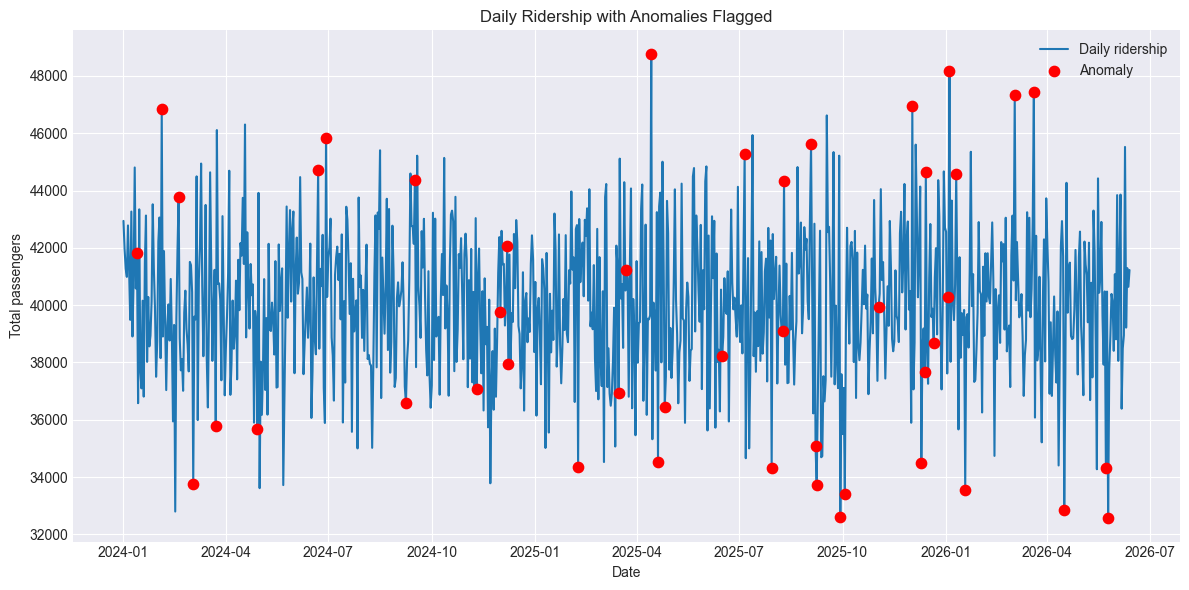

In [9]:
print("Plotting the ridership time series and flagged anomalies...")
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_daily["full_date"], df_daily["total_passengers"], linewidth=1.5, label="Daily ridership")
ax.scatter(
    anomalies["full_date"], anomalies["total_passengers"],
    color="red", s=55, label="Anomaly", zorder=3
)
ax.set_title("Daily Ridership with Anomalies Flagged")
ax.set_xlabel("Date")
ax.set_ylabel("Total passengers")
ax.legend()
fig.tight_layout()
fig.savefig(model_dir / "anomaly_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

Plotting the anomaly score distribution...


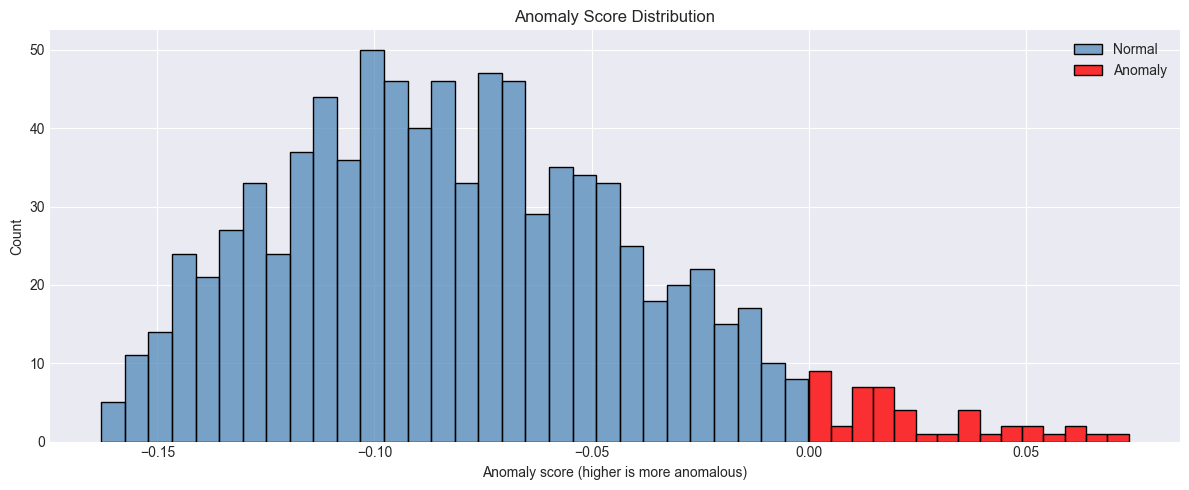

In [10]:
print("Plotting the anomaly score distribution...")
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(
    data=df_daily[df_daily["anomaly"] == 0], x="anomaly_score",
    bins=30, color="steelblue", label="Normal", alpha=0.7, ax=ax
)
sns.histplot(
    data=anomalies, x="anomaly_score",
    bins=15, color="red", label="Anomaly", alpha=0.8, ax=ax
)
ax.set_title("Anomaly Score Distribution")
ax.set_xlabel("Anomaly score (higher is more anomalous)")
ax.legend()
fig.tight_layout()
fig.savefig(model_dir / "anomaly_score_dist.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("Saving anomaly results...")
anomaly_results = anomalies[[
    "full_date", "total_passengers", "avg_delay", "anomaly_score"
]]
anomaly_results.to_csv(model_dir / "anomaly_results.csv", index=False)
print("Saved anomaly_results.csv")

Saving anomaly results...
Saved anomaly_results.csv


## Summary

IsolationForest flags days whose combined ridership, delay, trip-volume, and calendar patterns differ most from typical days. The highest anomaly scores identify the strongest departures from normal operations. With `contamination=0.05`, the model is instructed to classify approximately 5% of observed days as anomalous; these dates are candidates for operational review rather than automatic proof of a problem.